 Federated Quantum CNN using SDG (momentum=0.9)

In [ ]:
import os
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

In [105]:
import tensorflow as tf
tf.config.run_functions_eagerly(True)


In [106]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try: # allow memory growth
        for g in gpus:
            tf.config.experimental.set_memory_growth(g, True)
    except Exception as e:
        print("GPU config error:", e)


In [107]:
import os
import time
import csv
import json
import gc
import warnings
from datetime import datetime

import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, Callback
from tensorflow.python.framework.errors_impl import ResourceExhaustedError
from tensorflow.keras.optimizers import Optimizer 
from tensorflow.keras.saving import register_keras_serializable
import pennylane as qml
from sklearn.model_selection import KFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support


In [108]:
# -------------------------
# Configuration (tweak here)
# -------------------------
IMG_SIZE = (64, 64)
BATCH_SIZE = 16
NUM_CLIENTS = 5
NUM_FEDERATED_ROUNDS = 5
LOCAL_EPOCHS = 6
K_FOLDS = 5
NUM_CLASSES = 4
CLASS_NAMES = ['glioma', 'meningioma', 'notumor', 'pituitary']
LEARNING_RATE=0.001
BETA=0.9
GAMMA=1e-7

# Quantum settings
N_QUBITS = 4
N_LAYERS = 2
TOTAL_SHOTS = 1000            
USE_NOISE = True
NOISE_PROB = 0.02             # depolarizing probability

In [109]:
# Create folders
os.makedirs("flq-logs", exist_ok=True)
os.makedirs("flq-models", exist_ok=True)
os.makedirs("flq-tmp_models", exist_ok=True)
os.makedirs("flq-visuals", exist_ok=True)

In [110]:
# reproducibility
np.random.seed(42)
tf.random.set_seed(42)
sns.set_theme(style="whitegrid", font_scale=1.1)

In [111]:
@register_keras_serializable(package="custom", name="AdamSGDHybrid")
class AdamSGDHybrid(tf.keras.optimizers.Optimizer):

    def __init__(
        self,
        learning_rate=0.001,
        beta1=0.9,
        beta2=0.999,
        epsilon=1e-7,
        momentum=0.9,
        mix_factor=0.5,
        name="AdamSGDHybrid",
        **kwargs
    ):
        super().__init__(learning_rate=learning_rate, name=name, **kwargs)
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon
        self.momentum = momentum
        self.mix_factor = mix_factor

    def build(self, var_list):
        self.m = []
        self.v = []
        self.sgd_mom = []

        for var in var_list:
            self.m.append(self.add_variable_from_reference(var, "m"))
            self.v.append(self.add_variable_from_reference(var, "v"))
            self.sgd_mom.append(self.add_variable_from_reference(var, "sgd_mom"))

        super().build(var_list)

    def update_step(self, grad, var, lr):
        if grad is None:
            return

        idx = self._get_variable_index(var)

        m = self.m[idx]
        v = self.v[idx]
        sgd_mom = self.sgd_mom[idx]

        # Adam update
        m.assign(self.beta1 * m + (1. - self.beta1) * grad)
        v.assign(self.beta2 * v + (1. - self.beta2) * tf.square(grad))
        adam_update = m / (tf.sqrt(v) + self.epsilon)

        # SGD momentum update
        sgd_mom.assign(self.momentum * sgd_mom + grad)
        sgd_update = sgd_mom

        # Hybrid update
        update = self.mix_factor * adam_update + (1. - self.mix_factor) * sgd_update
        var.assign_sub(lr * update)

    def get_config(self):
        config = super().get_config()
        config.update({
            "beta1": self.beta1,
            "beta2": self.beta2,
            "epsilon": self.epsilon,
            "momentum": self.momentum,
            "mix_factor": self.mix_factor,
        })
        return config


In [112]:
# hybrid_optimizer=AdamSGDHybrid(
#     learning_rate=0.001,
#     momentum=0.9,
#     mix_factor=0.5   
# )

In [113]:
# -------------------------
# Quantum circuit (with depolarizing noise)
# -------------------------
def quantum_circuit(inputs, weights):
    """
    Quantum circuit with encoding, optional depolarizing noise, variational layers and measurements.
    """
    # data encoding
    for i in range(N_QUBITS):
        qml.RY(inputs[i], wires=i)

    # optional depolarizing noise after encoding
    if USE_NOISE and NOISE_PROB > 0:
        for i in range(N_QUBITS):
            qml.DepolarizingChannel(NOISE_PROB, wires=i)

    # variational layers
    for layer in range(N_LAYERS):
        for i in range(N_QUBITS):
            qml.RY(weights[layer, i, 0], wires=i)
            qml.RZ(weights[layer, i, 1], wires=i)

        # entanglement
        for i in range(N_QUBITS - 1):
            qml.CNOT(wires=[i, i + 1])
        qml.CNOT(wires=[N_QUBITS - 1, 0])

        # depolarizing noise between layers (optional)
        if USE_NOISE and NOISE_PROB > 0:
            for i in range(N_QUBITS):
                qml.DepolarizingChannel(NOISE_PROB, wires=i)

    # return expectation values
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

In [114]:
# Helper: create a qnode with shots safely (handles deprecation across PL versions)
def make_qnode_with_shots(shots):
    """
    Build a qnode that uses 'shots' either via device or transform depending on PennyLane version.
    """
    # attempt to use direct device creation with shots while suppressing deprecation warning
    try:
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", category=qml.PennyLaneDeprecationWarning)
            dev = qml.device("default.qubit", wires=N_QUBITS, shots=shots)
        qnode = qml.QNode(quantum_circuit, dev, interface='autograd')
        return qnode
    except Exception:
        # fallback: create device without shots and wrap with set_shots transform if available
        try:
            dev = qml.device("default.qubit", wires=N_QUBITS)
            qnode = qml.QNode(quantum_circuit, dev, interface='autograd')
            try:
                from pennylane.transforms import set_shots
                qnode = set_shots(shots)(qnode)
                return qnode
            except Exception:
                # final fallback: return qnode without explicit shots; PennyLane will use analytic mode
                return qnode
        except Exception:
            raise

In [99]:
# -------------------------
# QuantumInspiredLayer (same as before) with optional qnode demonstration
# -------------------------
class QuantumInspiredLayer(layers.Layer):
    def __init__(self, n_qubits, n_layers, **kwargs):
        super().__init__(**kwargs)
        self.n_qubits = n_qubits
        self.n_layers = n_layers

    def build(self, input_shape):
        self.rotation_weights = self.add_weight(
            name="rotation_weights",
            shape=(self.n_layers, self.n_qubits, 2),
            initializer=keras.initializers.RandomUniform(0, 2*np.pi),
            trainable=True
        )
        self.interaction_weights = self.add_weight(
            name="interaction_weights",
            shape=(self.n_layers, self.n_qubits, self.n_qubits),
            initializer=keras.initializers.GlorotUniform(),
            trainable=True
        )
        super().build(input_shape)

    def call(self, inputs):
        x = inputs
        for layer in range(self.n_layers):
            ry_transform = tf.cos(self.rotation_weights[layer, :, 0]) * x + \
                          tf.sin(self.rotation_weights[layer, :, 0]) * tf.roll(x, shift=1, axis=-1)
            rz_transform = tf.cos(self.rotation_weights[layer, :, 1]) * ry_transform - \
                          tf.sin(self.rotation_weights[layer, :, 1]) * tf.roll(ry_transform, shift=-1, axis=-1)
            interaction = tf.matmul(tf.expand_dims(rz_transform, -1), tf.expand_dims(rz_transform, -2))
            interaction_effect = tf.reduce_sum(interaction * self.interaction_weights[layer], axis=-1)
            x = tf.tanh(rz_transform + 0.1 * interaction_effect)
        return x



In [100]:
# -------------------------
# Client data loader
# -------------------------
class ClientSequence(keras.utils.Sequence):
    def __init__(self, filepaths, labels, img_size=IMG_SIZE, batch_size=BATCH_SIZE, num_classes=NUM_CLASSES, shuffle=True):
        self.filepaths = np.array(filepaths)
        self.labels = np.array(labels)
        self.img_size = img_size
        self.batch_size = batch_size
        self.num_classes = num_classes
        self.shuffle = shuffle
        self.indexes = np.arange(len(self.filepaths))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.filepaths) / self.batch_size))

    def __getitem__(self, index):
        batch_idx = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_files = self.filepaths[batch_idx]
        batch_labels = self.labels[batch_idx]
        X = np.zeros((len(batch_files), *self.img_size, 3), dtype=np.float32)
        y = np.zeros((len(batch_files), self.num_classes), dtype=np.float32)
        for i, fp in enumerate(batch_files):
            img = cv2.imread(fp)
            if img is None:
                img = np.zeros((self.img_size[0], self.img_size[1], 3), dtype=np.uint8)
            else:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, self.img_size)
            img = img.astype(np.float32) / 255.0
            y[i, int(batch_labels[i])] = 1.0
            X[i] = img
        return X, y

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indexes)


In [ ]:
# -------------------------
# Timing callback for epochs
# -------------------------
class TimingCallback(Callback):
    def __init__(self, round_no, client_id, epoch_records):
        super().__init__()
        self.round_no = round_no
        self.client_id = client_id
        self.epoch_times = []
        self.epoch_records = epoch_records

    def on_epoch_begin(self, epoch, logs=None):
        self._start = time.time()

    def on_epoch_end(self, epoch, logs=None):
        t = time.time() - self._start
        self.epoch_times.append(t)
        # safe get lr
        try:
            lr = float(tf.keras.backend.get_value(self.model.optimizer.learning_rate))
            loss = float(logs["loss"])

        except Exception:
            lr = None
            loss=None
        train_acc = logs.get('accuracy')
        val_acc = logs.get('val_accuracy')
        train_loss = logs.get('loss')
        val_loss = logs.get('val_loss')
        self.epoch_records.append([self.round_no, self.client_id, epoch+1, t, train_acc, val_acc, train_loss, val_loss, lr])
        print(f"⏱ [R{self.round_no} C{self.client_id}] Epoch {epoch+1} time={t:.2f}s train_acc={train_acc:.4f} val_acc={val_acc}")


In [115]:
# -------------------------
# Federated Quantum CNN class
# -------------------------
class FederatedQuantumCNN:
    def __init__(self, num_clients=NUM_CLIENTS, img_size=IMG_SIZE, num_classes=NUM_CLASSES, class_names=CLASS_NAMES):
        self.num_clients = num_clients
        self.img_size = img_size
        self.num_classes = num_classes
        self.class_names = class_names
        self.n_qubits = N_QUBITS
        self.n_layers = N_LAYERS
        self.global_model = None
        self.history = {'val_accuracy': [], 'val_loss': []}

    def create_quantum_cnn_model(self):
        inputs = layers.Input(shape=(*self.img_size, 3))
        # conv blocks
        x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
        x = layers.BatchNormalization()(x)
        x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D((2,2))(x)
        x = layers.Dropout(0.25)(x)

        x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D((2,2))(x)
        x = layers.Dropout(0.25)(x)

        x = layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D((2,2))(x)
        x = layers.Dropout(0.25)(x)

        x = layers.Flatten()(x)
        x = layers.Dense(64, activation='relu')(x)
        x = layers.Dropout(0.5)(x)

        x = layers.Dense(self.n_qubits, activation='tanh', name='quantum_input')(x)
        x = QuantumInspiredLayer(self.n_qubits, self.n_layers, name='quantum_layer')(x)
        outputs = layers.Dense(self.num_classes, activation='softmax')(x)

        model = models.Model(inputs=inputs, outputs=outputs)
       
        model.compile(
            optimizer=AdamSGDHybrid(
                learning_rate=0.001,
                momentum=0.9,
                mix_factor=0.5   
            ),
            loss='categorical_crossentropy',
            metrics=['accuracy'],
            run_eagerly=True
        )
        return model

    def load_data_generators(self, train_dir, test_dir, batch_size=BATCH_SIZE):
        train_datagen = ImageDataGenerator(
            rescale=1./255,
            rotation_range=20,
            width_shift_range=0.2,
            height_shift_range=0.2,
            horizontal_flip=True,
            zoom_range=0.2,
            fill_mode='nearest',
            validation_split=0.2
        )
        test_datagen = ImageDataGenerator(rescale=1./255)

        train_generator = train_datagen.flow_from_directory(train_dir, target_size=self.img_size,
                                                            batch_size=batch_size, class_mode='categorical',
                                                            subset='training', shuffle=True)
        val_generator = train_datagen.flow_from_directory(train_dir, target_size=self.img_size,
                                                          batch_size=batch_size, class_mode='categorical',
                                                          subset='validation', shuffle=False)
        test_generator = test_datagen.flow_from_directory(test_dir, target_size=self.img_size,
                                                          batch_size=batch_size, class_mode='categorical',
                                                          shuffle=False)
        idx_to_class = {v:k for k,v in train_generator.class_indices.items()}
        self.class_names = [idx_to_class[i] for i in range(len(idx_to_class))]
        return train_generator, val_generator, test_generator

    def split_filepaths_for_clients(self, train_generator):
        filepaths = np.array(train_generator.filepaths)
        labels = np.array(train_generator.classes, dtype=int)
        indices = np.arange(len(filepaths))
        np.random.shuffle(indices)
        splits = np.array_split(indices, self.num_clients)
        client_filelists = []
        for s in splits:
            client_filelists.append((filepaths[s].tolist(), labels[s].tolist()))
        return client_filelists

    def train_federated(self, train_dir, val_generator, num_rounds=NUM_FEDERATED_ROUNDS, local_epochs=LOCAL_EPOCHS,
                        batch_size=BATCH_SIZE, start_round=1, total_shots=TOTAL_SHOTS):
        """
        Federated training that:
         - gives each client a qnode with client-specific shots,
         - measures epoch and round times,
         - computes communication bytes,
         - saves logs (CSV) and checkpoints per round.
        """
        print("\n========== FEDERATED QUANTUM CNN TRAINING STARTED ==========")
        print(f"Clients: {self.num_clients}, Rounds: {num_rounds}, Local epochs: {local_epochs}")
        client_shots = max(1, total_shots // max(1, self.num_clients))
        print(f"Total shots: {total_shots}, shots per client: {client_shots}")

        if self.global_model is None:
            if start_round > 1:
                raise ValueError("Load checkpoint into self.global_model before resuming.")
            self.global_model = self.create_quantum_cnn_model()

        base_datagen = ImageDataGenerator(rescale=1./255)
        base_gen = base_datagen.flow_from_directory(train_dir, target_size=self.img_size,
                                                    batch_size=batch_size, class_mode='categorical', shuffle=False)
        client_filelists = self.split_filepaths_for_clients(base_gen)

        # Logs
        epoch_records = []    # [round, client, epoch, time, train_acc, val_acc, train_loss, val_loss, lr]
        comm_records = []     # [round, client, bytes_server_to_client, bytes_client_to_server]
        round_summary = []    # [round, total_comm_bytes, round_time_sec, val_loss, val_acc]

        for round_num in range(start_round - 1, num_rounds):
            print(f"\n{'='*70}\nROUND {round_num + 1}/{num_rounds}\n{'='*70}")
            round_start = time.time()
            client_weights = []
            total_comm = 0
            per_client_times = []

            for client_id, (filepaths, labels) in enumerate(client_filelists):
                print(f"\n-> Client {client_id+1} | samples: {len(filepaths)}")
                # compute bytes server->client
                server_weights = self.global_model.get_weights()
                bytes_s_to_c = sum([w.nbytes for w in server_weights])
                print(f"   bytes server->client: {bytes_s_to_c:,}")

                tf.keras.backend.clear_session()
                # create client model & load global weights
                client_model = self.create_quantum_cnn_model()
                client_model.set_weights(self.global_model.get_weights())

                # prepare per-client qnode with shots (for optional quantum demo usage)
                try:
                    client_qnode = make_qnode_with_shots(client_shots)
                except Exception as e:
                    client_qnode = None
                    print("   Warning: could not create per-client qnode:", e)

                # train client
                seq = ClientSequence(filepaths, labels, img_size=self.img_size, batch_size=batch_size,
                                     num_classes=self.num_classes, shuffle=True)
                timing_cb = TimingCallback(round_num+1, client_id+1, epoch_records)
                callbacks = [timing_cb, EarlyStopping(patience=3, restore_best_weights=True, verbose=0, monitor='loss'),
                             ReduceLROnPlateau(factor=0.5, patience=2, verbose=0, monitor='loss')]

                client_start = time.time()
                try:
                    client_model.fit(seq, epochs=local_epochs, verbose=1, callbacks=callbacks)
                except ResourceExhaustedError as oom:
                    print("   !! OOM on client training:", oom)
                    # attempt simple recovery: try smaller batch, reload model, etc.
                    tf.keras.backend.clear_session()
                    gc.collect()
                    raise

                client_time = time.time() - client_start
                per_client_times.append(client_time)
                print(f"   client training time: {client_time:.2f}s")

                # compute bytes client->server
                client_w = client_model.get_weights()
                bytes_c_to_s = sum([w.nbytes for w in client_w])
                print(f"   bytes client->server: {bytes_c_to_s:,}")

                comm_records.append([round_num+1, client_id+1, bytes_s_to_c, bytes_c_to_s])
                total_comm += (bytes_s_to_c + bytes_c_to_s)

                client_weights.append(client_w)

                # cleanup
                try:
                    tf.keras.backend.clear_session()
                    del client_model
                except Exception:
                    pass
                gc.collect()

            # federated averaging
            print("\nAggregating (FedAvg)...")
            averaged = []
            for layer_weights in zip(*client_weights):
                stacked = np.stack(layer_weights, axis=0)
                averaged.append(np.mean(stacked, axis=0))
            self.global_model.set_weights(averaged)

            # evaluate global on validation set
            print("Evaluating global model on validation set...")
            val_loss, val_acc = self.global_model.evaluate(val_generator, verbose=1)
            print(f"[Round {round_num+1}] val_acc={val_acc:.4f} val_loss={val_loss:.4f}")

            # save checkpoint per round
            ckpt = os.path.join("flq-models", f"federated_quantum_model_round_{round_num+1}.keras")
            try:
                self.global_model.save(ckpt)
                print(f"Saved checkpoint: {ckpt}")
            except Exception as e:
                print("Warning: could not save checkpoint:", e)

            round_time = time.time() - round_start
            round_summary.append([round_num+1, total_comm, round_time, float(val_loss), float(val_acc)])
            # update history
            self.history['val_loss'].append(float(val_loss))
            self.history['val_accuracy'].append(float(val_acc))
            gc.collect()

        # Save logs to CSVs
        epoch_csv = os.path.join("flq-logs", "federated_epoch_times.csv")
        with open(epoch_csv, "w", newline="") as f:
            w = csv.writer(f)
            w.writerow(["Round", "Client", "Epoch", "TimeSec", "TrainAcc", "ValAcc", "TrainLoss", "ValLoss", "LR"])
            w.writerows(epoch_records)
        print(f"Saved epoch-level logs: {epoch_csv}")

        comm_csv = os.path.join("flq-logs", "comm_bytes_per_round.csv")
        with open(comm_csv, "w", newline="") as f:
            w = csv.writer(f)
            w.writerow(["Round", "Client", "Bytes_Server_to_Client", "Bytes_Client_to_Server"])
            w.writerows(comm_records)
        print(f"Saved comm bytes logs: {comm_csv}")

        round_csv = os.path.join("flq-logs", "federated_round_summary.csv")
        with open(round_csv, "w", newline="") as f:
            w = csv.writer(f)
            w.writerow(["Round", "Total_Comm_Bytes", "RoundTimeSec", "ValLoss", "ValAcc"])
            w.writerows(round_summary)
        print(f"Saved round summary: {round_csv}")

        # summary JSON
        summary = {
            "timestamp": datetime.now().isoformat(),
            "num_clients": self.num_clients,
            "num_rounds": num_rounds,
            "local_epochs": local_epochs,
            "total_shots": total_shots,
            "shots_per_client": client_shots,
            "noise": {"use_noise": USE_NOISE, "noise_prob": NOISE_PROB}
        }
        with open(os.path.join("flq-logs", "federated_run_summary.json"), "w") as f:
            json.dump(summary, f, indent=2)
        print("Saved run summary JSON")

        print("\nFEDERATED TRAINING COMPLETE")
        return self.global_model

    def kfold_cross_validation(self, train_dir, k_folds=K_FOLDS, batch_size=BATCH_SIZE):
        print("\nK-FOLD CROSS-VALIDATION (Quantum CNN)")

        datagen = ImageDataGenerator(rescale=1./255)
        full_gen = datagen.flow_from_directory(
            train_dir,
            target_size=self.img_size,
            batch_size=batch_size,
            class_mode='categorical',
            shuffle=False
        )

        filepaths = np.array(full_gen.filepaths)
        labels = np.array(full_gen.classes, dtype=int)

        kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)
        fold_scores = []

        for fold, (train_idx, val_idx) in enumerate(kf.split(filepaths)):
            print(f"\n-- Fold {fold+1}/{k_folds} --")
            tf.keras.backend.clear_session()
            train_seq = ClientSequence(
                filepaths[train_idx],
                labels[train_idx],
                img_size=self.img_size,
                batch_size=batch_size,
                num_classes=self.num_classes,
                shuffle=True
            )

            val_seq = ClientSequence(
                filepaths[val_idx],
                labels[val_idx],
                img_size=self.img_size,
                batch_size=batch_size,
                num_classes=self.num_classes,
                shuffle=False
            )

            model = self.create_quantum_cnn_model()

            model.fit(
                train_seq,
                validation_data=val_seq,
                epochs=30,
                callbacks=[
                    EarlyStopping(patience=5, restore_best_weights=True),
                    ReduceLROnPlateau(patience=3)
                ],
                verbose=1
            )

            _, acc = model.evaluate(val_seq, verbose=0)
            fold_scores.append(float(acc))
            print(f"Fold {fold+1} Accuracy: {acc:.4f}")
            
            tf.keras.backend.clear_session()
            del model
            gc.collect()

        return fold_scores


    def evaluate_model(self, test_generator):
        print("\nEVALUATING ON TEST SET")
        y_pred_probs = self.global_model.predict(test_generator, verbose=1)
        y_pred = np.argmax(y_pred_probs, axis=1)
        y_true = test_generator.classes
        acc = accuracy_score(y_true, y_pred)
        print(f"Test Accuracy: {acc:.4f}")
        report = classification_report(y_true, y_pred, target_names=self.class_names, digits=4)
        print(report)
        # save classification report
        with open(os.path.join("flq-logs", "classification_report.txt"), "w") as f:
            f.write(report)
        cm = confusion_matrix(y_true, y_pred)
        # per-class metrics
        precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred, average=None)
        for i, cname in enumerate(self.class_names):
            print(f"{cname}: prec={precision[i]:.4f} rec={recall[i]:.4f} f1={f1[i]:.4f} sup={support[i]}")
        return y_true, y_pred, y_pred_probs, cm, acc

    def plot_training_history(self):
        # validation accuracy / loss per round
        fig, ax = plt.subplots(1,2, figsize=(14,5))
        ax[0].plot(range(1, len(self.history['val_accuracy'])+1), self.history['val_accuracy'], marker='o', color='#007acc')
        ax[0].set_title('Validation Accuracy per Round'); ax[0].set_xlabel('Round'); ax[0].set_ylabel('Accuracy'); ax[0].grid(True)
        ax[1].plot(range(1, len(self.history['val_loss'])+1), self.history['val_loss'], marker='o', color='#ff4d4d')
        ax[1].set_title('Validation Loss per Round'); ax[1].set_xlabel('Round'); ax[1].set_ylabel('Loss'); ax[1].grid(True)
        plt.tight_layout(); plt.savefig('visuals/fqcnn_training_history.png', dpi=300, bbox_inches='tight'); plt.show()
        print("Saved visuals/fqcnn_training_history.png")

    def plot_confusion_matrix(self, cm):
        plt.figure(figsize=(9,7))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=self.class_names, yticklabels=self.class_names)
        plt.title('Confusion Matrix'); plt.xlabel('Predicted'); plt.ylabel('True')
        plt.tight_layout(); plt.savefig('visuals/fqcnn_confusion_matrix.png', dpi=300, bbox_inches='tight'); plt.show()
        print("Saved visuals/fqcnn_confusion_matrix.png")

    def plot_performance_metrics(self, y_true, y_pred):
        precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average=None)
        x = np.arange(len(self.class_names)); w=0.25
        fig, ax = plt.subplots(figsize=(10,5))
        ax.bar(x-w, precision, w, label='Precision'); ax.bar(x, recall, w, label='Recall'); ax.bar(x+w, f1, w, label='F1')
        ax.set_xticks(x); ax.set_xticklabels(self.class_names, rotation=45); ax.set_ylim([0,1.05]); ax.legend()
        plt.tight_layout(); plt.savefig('visuals/fqcnn_performance_metrics.png', dpi=300, bbox_inches='tight'); plt.show()
        print("Saved visuals/fqcnn_performance_metrics.png")

    def visualize_quantum_layer(self, test_generator, num_samples=4, shots_each=TOTAL_SHOTS//NUM_CLIENTS):
        print("Visualizing quantum layer activations (demonstration using qnode if available)...")
        quantum_model = keras.Model(inputs=self.global_model.input, outputs=self.global_model.get_layer('quantum_layer').output)
        # sample some images
        test_images = []
        test_labels = []
        it = iter(test_generator)
        for _ in range(num_samples):
            try:
                bx, by = next(it)
            except StopIteration:
                it = iter(test_generator); bx, by = next(it)
            test_images.append(bx[0]); test_labels.append(np.argmax(by[0]))
        fig, axes = plt.subplots(num_samples, 2, figsize=(12,3*num_samples))
        for i in range(num_samples):
            img = np.expand_dims(test_images[i], axis=0)
            qout = quantum_model.predict(img, verbose=0)[0]
            axes[i,0].imshow(test_images[i]); axes[i,0].axis('off'); axes[i,0].set_title(f"Input: {self.class_names[test_labels[i]]}")
            axes[i,1].bar(range(self.n_qubits), qout); axes[i,1].set_ylim([-1,1]); axes[i,1].set_title('Quantum Layer Activations')
        plt.tight_layout(); plt.savefig('visuals/fqcnn_quantum_activations.png', dpi=300, bbox_inches='tight'); plt.show()
        print("Saved visuals/fqcnn_quantum_activations.png")

    def save_results(self, fold_scores, test_accuracy):
        results = {
            'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
            'model': 'Federated Quantum CNN',
            'num_clients': self.num_clients,
            'kfold': { 'fold_scores': fold_scores, 'mean': float(np.mean(fold_scores)), 'std': float(np.std(fold_scores)) },
            'test_accuracy': float(test_accuracy),
            'training_history': self.history
        }
        with open('flq-logs/federated_quantum_cnn_results.json', 'w') as f:
            json.dump(results, f, indent=2)
        print("Saved logs/federated_quantum_cnn_results.json")

In [116]:
# MAIN
# -------------------------
def main():
    TRAIN_DIR = '/mnt/c/Users/hassa/OneDrive/Desktop/QML/Brain_Tumor_data/Training'
    TEST_DIR = '/mnt/c/Users/hassa/OneDrive/Desktop/QML/Brain_Tumor_data/Testing'
    fqcnn = FederatedQuantumCNN(num_clients=NUM_CLIENTS, img_size=IMG_SIZE)
    train_gen, val_gen, test_gen = fqcnn.load_data_generators(TRAIN_DIR, TEST_DIR, batch_size=BATCH_SIZE)
    print(f"Dataset: train {train_gen.samples}, val {val_gen.samples}, test {test_gen.samples}")

    # Phase 1: K-Fold centralized baseline
    start = time.time()
    fold_scores = fqcnn.kfold_cross_validation(TRAIN_DIR, k_folds=K_FOLDS, batch_size=BATCH_SIZE)
    print(f"K-fold time: {time.time()-start:.2f}s")

    # Phase 2: Federated training
    start = time.time()
    global_model = fqcnn.train_federated(TRAIN_DIR, val_gen, num_rounds=NUM_FEDERATED_ROUNDS,
                                         local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE, start_round=1, total_shots=TOTAL_SHOTS)
    print(f"Federated training time: {time.time()-start:.2f}s")

    fqcnn.plot_training_history()

    # Phase 3: Evaluate
    y_true, y_pred, y_pred_probs, cm, test_acc = fqcnn.evaluate_model(test_gen)
    fqcnn.plot_confusion_matrix(cm)
    fqcnn.plot_performance_metrics(y_true, y_pred)
    fqcnn.visualize_quantum_layer(test_gen, num_samples=4)

    fqcnn.save_results(fold_scores, test_acc)

    # Save final model
    try:
        global_model.save('flq-models/federated_quantum_brain_tumor_model.keras')
        global_model.save('Final_federated_quantum_CNN_model.keras')
        print("Saved final model to models/federated_quantum_brain_tumor_model.keras")
    except Exception as e:
        print("Could not save final model:", e)

Found 4571 images belonging to 4 classes.
Found 1141 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.
Dataset: train 4571, val 1141, test 1311

K-FOLD CROSS-VALIDATION (Quantum CNN)
Found 5712 images belonging to 4 classes.

-- Fold 1/5 --


/mnt/c/Users/hassa/OneDrive/Desktop/QML/.venv/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
/mnt/c/Users/hassa/OneDrive/Desktop/QML/.venv/lib/python3.12/site-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


Epoch 1/30
286/286 ━━━━━━━━━━━━━━━━━━━━ 70s 236ms/step - accuracy: 0.4601 - loss: 1.2606 - val_accuracy: 0.2703 - val_loss: 1.4556 - learning_rate: 0.0010
Epoch 2/30
286/286 ━━━━━━━━━━━━━━━━━━━━ 69s 241ms/step - accuracy: 0.5275 - loss: 1.1347 - val_accuracy: 0.3876 - val_loss: 1.3629 - learning_rate: 0.0010
Epoch 3/30
286/286 ━━━━━━━━━━━━━━━━━━━━ 67s 234ms/step - accuracy: 0.5677 - loss: 1.0669 - val_accuracy: 0.5127 - val_loss: 1.0913 - learning_rate: 0.0010
Epoch 4/30
286/286 ━━━━━━━━━━━━━━━━━━━━ 67s 235ms/step - accuracy: 0.5846 - loss: 1.0443 - val_accuracy: 0.3010 - val_loss: 1.6603 - learning_rate: 0.0010
Epoch 5/30
286/286 ━━━━━━━━━━━━━━━━━━━━ 66s 230ms/step - accuracy: 0.5743 - loss: 1.0474 - val_accuracy: 0.5389 - val_loss: 1.1557 - learning_rate: 0.0010
Epoch 6/30
286/286 ━━━━━━━━━━━━━━━━━━━━ 64s 225ms/step - accuracy: 0.5874 - loss: 0.9992 - val_accuracy: 0.6142 - val_loss: 0.9807 - learning_rate: 0.0010
Epoch 7/30
286/286 ━━━━━━━━━━━━━━━━━━━━ 66s 231ms/step - accuracy: 0.5

/mnt/c/Users/hassa/OneDrive/Desktop/QML/.venv/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
/mnt/c/Users/hassa/OneDrive/Desktop/QML/.venv/lib/python3.12/site-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - accuracy: 0.2815 - loss: 1.4980⏱ [R1 C1] Epoch 1 time=15.54s train_acc=0.2712 val_acc=None
72/72 ━━━━━━━━━━━━━━━━━━━━ 16s 211ms/step - accuracy: 0.2712 - loss: 1.4463 - learning_rate: 0.0010
Epoch 2/6
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - accuracy: 0.4223 - loss: 1.3483⏱ [R1 C1] Epoch 2 time=14.79s train_acc=0.4033 val_acc=None
72/72 ━━━━━━━━━━━━━━━━━━━━ 15s 204ms/step - accuracy: 0.4033 - loss: 1.3371 - learning_rate: 0.0010
Epoch 3/6
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - accuracy: 0.4304 - loss: 1.2889⏱ [R1 C1] Epoch 3 time=15.40s train_acc=0.3718 val_acc=None
72/72 ━━━━━━━━━━━━━━━━━━━━ 15s 213ms/step - accuracy: 0.3718 - loss: 1.3256 - learning_rate: 0.0010
Epoch 4/6
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.3415 - loss: 1.3211⏱ [R1 C1] Epoch 4 time=15.00s train_acc=0.3342 val_acc=None
72/72 ━━━━━━━━━━━━━━━━━━━━ 15s 207ms/step - accuracy: 0.3342 - loss: 1.3280 - learning_rate: 0.0010
Epoch 5/6
72/72 ━━━━━━━━━━━━━━━━━━

...

/mnt/c/Users/hassa/OneDrive/Desktop/QML/.venv/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
/mnt/c/Users/hassa/OneDrive/Desktop/QML/.venv/lib/python3.12/site-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - accuracy: 0.5442 - loss: 1.0981⏱ [R5 C4] Epoch 1 time=15.45s train_acc=0.5175 val_acc=None
72/72 ━━━━━━━━━━━━━━━━━━━━ 15s 211ms/step - accuracy: 0.5175 - loss: 1.1190 - learning_rate: 0.0010
Epoch 2/6
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - accuracy: 0.5220 - loss: 1.1281⏱ [R5 C4] Epoch 2 time=15.75s train_acc=0.5464 val_acc=None
72/72 ━━━━━━━━━━━━━━━━━━━━ 16s 218ms/step - accuracy: 0.5464 - loss: 1.0876 - learning_rate: 0.0010
Epoch 3/6
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.5662 - loss: 1.0442⏱ [R5 C4] Epoch 3 time=16.10s train_acc=0.5429 val_acc=None
72/72 ━━━━━━━━━━━━━━━━━━━━ 16s 223ms/step - accuracy: 0.5429 - loss: 1.0563 - learning_rate: 0.0010
Epoch 4/6
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.5281 - loss: 1.0265⏱ [R5 C4] Epoch 4 time=16.18s train_acc=0.5210 val_acc=None
72/72 ━━━━━━━━━━━━━━━━━━━━ 16s 223ms/step - accuracy: 0.5210 - loss: 1.0652 - learning_rate: 0.0010
Epoch 5/6
72/72 ━━━━━━━━━━━━━━━━━━

/mnt/c/Users/hassa/OneDrive/Desktop/QML/.venv/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
/mnt/c/Users/hassa/OneDrive/Desktop/QML/.venv/lib/python3.12/site-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.5608 - loss: 1.0280⏱ [R5 C5] Epoch 1 time=15.18s train_acc=0.5534 val_acc=None
72/72 ━━━━━━━━━━━━━━━━━━━━ 15s 206ms/step - accuracy: 0.5534 - loss: 1.0603 - learning_rate: 0.0010
Epoch 2/6
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - accuracy: 0.5488 - loss: 1.0380⏱ [R5 C5] Epoch 2 time=15.40s train_acc=0.5569 val_acc=None
72/72 ━━━━━━━━━━━━━━━━━━━━ 15s 213ms/step - accuracy: 0.5569 - loss: 1.0332 - learning_rate: 0.0010
Epoch 3/6
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.5235 - loss: 1.1296⏱ [R5 C5] Epoch 3 time=15.07s train_acc=0.5280 val_acc=None
72/72 ━━━━━━━━━━━━━━━━━━━━ 15s 208ms/step - accuracy: 0.5280 - loss: 1.1180 - learning_rate: 0.0010
Epoch 4/6
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - accuracy: 0.5151 - loss: 1.1127⏱ [R5 C5] Epoch 4 time=15.16s train_acc=0.5201 val_acc=None
72/72 ━━━━━━━━━━━━━━━━━━━━ 15s 209ms/step - accuracy: 0.5201 - loss: 1.0942 - learning_rate: 0.0010
Epoch 5/6
72/72 ━━━━━━━━━━━━━━━━━━

FileNotFoundError: [Errno 2] No such file or directory: 'visuals/fqcnn_training_history.png'

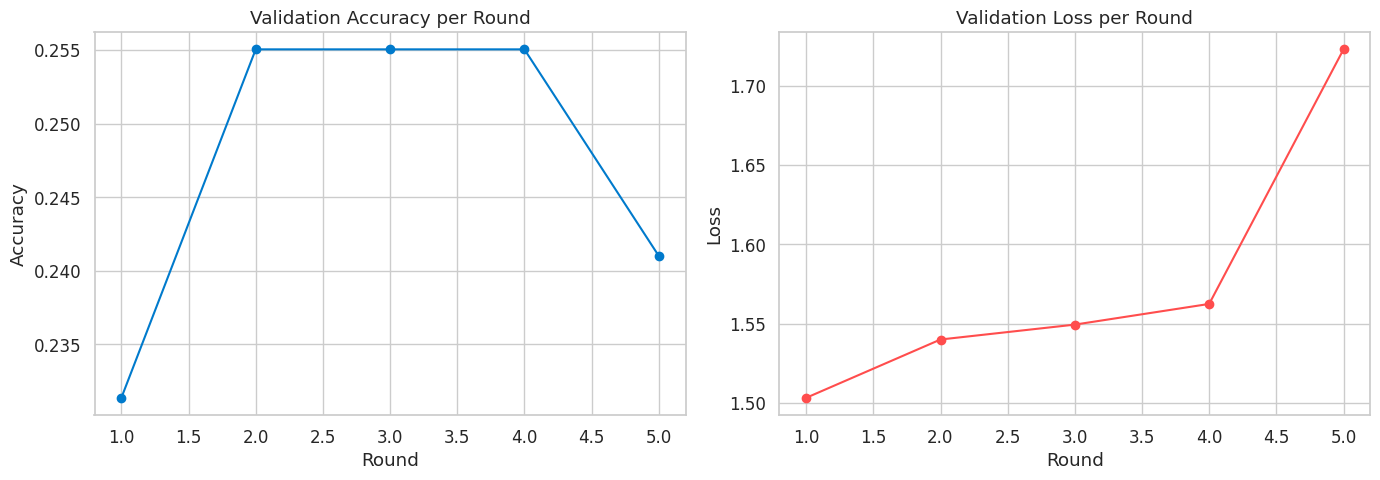

In [117]:
if __name__ == "__main__":
    main()

In [ ]:
# from tensorflow.keras.models import load_model

# model=load_model("flq-models/federated_quantum_model_round_5.keras",  custom_objects={"QuantumInspiredLayer": QuantumInspiredLayer})
# model.summary()

In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from matplotlib.ticker import FuncFormatter

sns.set(style="whitegrid", font_scale=1.2)
plt.rcParams["figure.figsize"] = (10, 6)


In [119]:
epoch_df = pd.read_csv("flq-logs/federated_epoch_times.csv")
round_df = pd.read_csv("flq-logs/federated_round_summary.csv")
comm_df = pd.read_csv("flq-logs/comm_bytes_per_round.csv")

print("Epoch Data:", epoch_df.shape)
print("Round Data:", round_df.shape)
print("Comm Data:", comm_df.shape)


Epoch Data: (144, 9)
Round Data: (5, 5)
Comm Data: (25, 4)


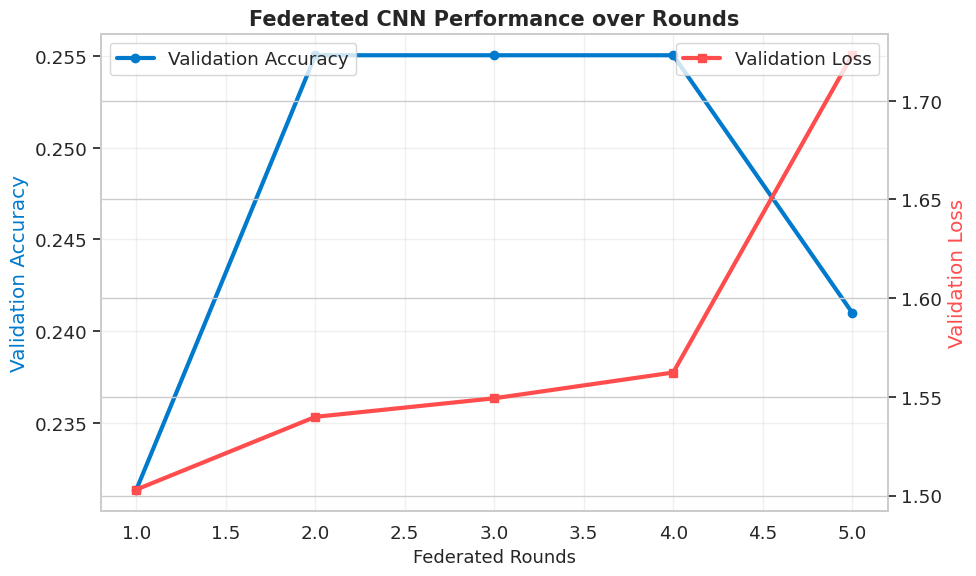

In [120]:
fig, ax1 = plt.subplots(figsize=(10,6))
ax1.plot(round_df['Round'], round_df['ValAcc'], color='#007acc', marker='o', lw=3, label='Validation Accuracy')
ax2 = ax1.twinx()
ax2.plot(round_df['Round'], round_df['ValLoss'], color='#ff4d4d', marker='s', lw=3, label='Validation Loss')

ax1.set_xlabel("Federated Rounds", fontsize=13)
ax1.set_ylabel("Validation Accuracy", color='#007acc')
ax2.set_ylabel("Validation Loss", color='#ff4d4d')
ax1.set_title("Federated CNN Performance over Rounds", fontsize=15, weight='bold')

ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()


/tmp/ipykernel_10979/2944798485.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Client', y='TimeSec', data=avg_epoch_time, palette='coolwarm')


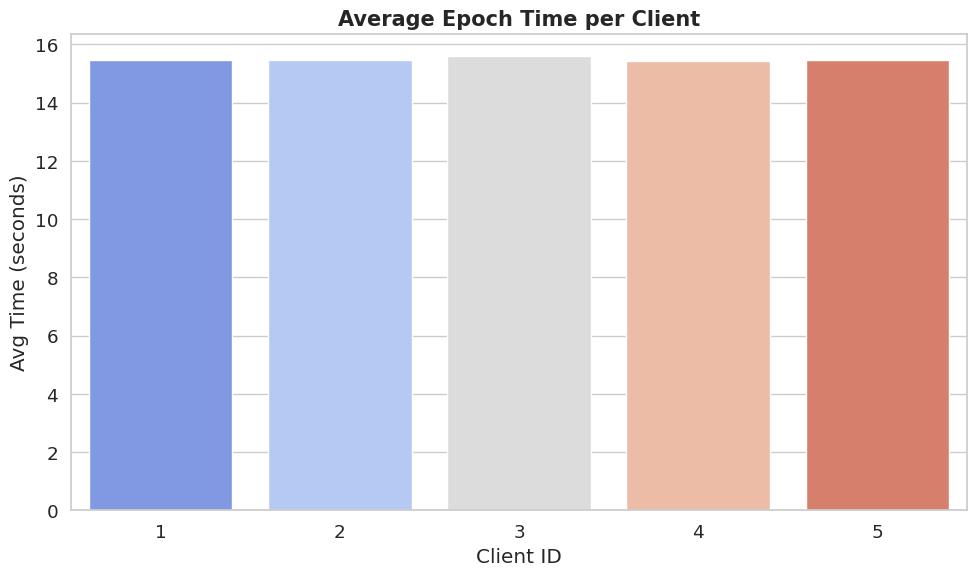

In [121]:
avg_epoch_time = epoch_df.groupby(['Client'])['TimeSec'].mean().reset_index()
sns.barplot(x='Client', y='TimeSec', data=avg_epoch_time, palette='coolwarm')
plt.title("Average Epoch Time per Client", fontsize=15, weight='bold')
plt.xlabel("Client ID")
plt.ylabel("Avg Time (seconds)")
plt.tight_layout()
plt.show()


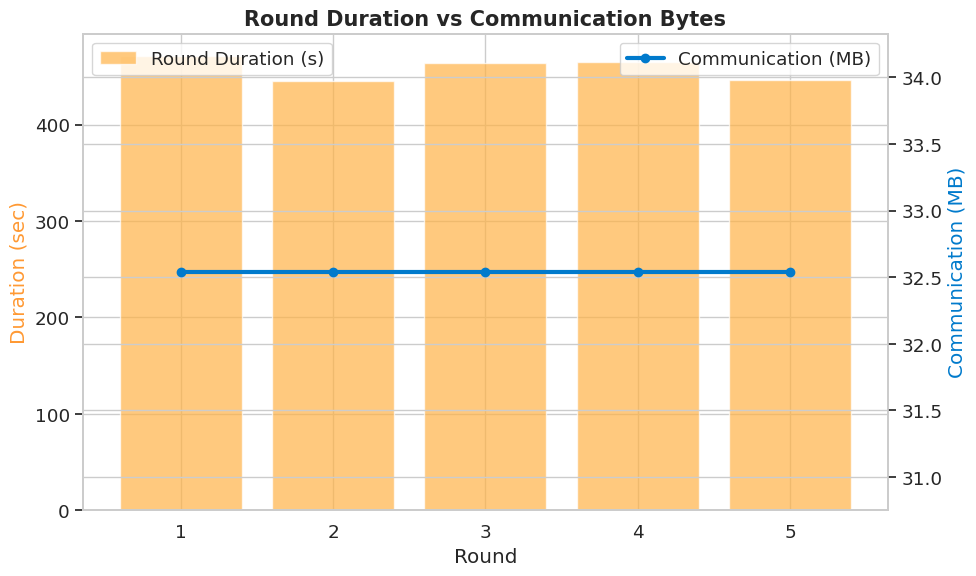

In [122]:
fig, ax1 = plt.subplots(figsize=(10,6))
ax1.bar(round_df['Round'], round_df['RoundTimeSec'], color='#ffb347', alpha=0.7, label='Round Duration (s)')
ax2 = ax1.twinx()
ax2.plot(round_df['Round'], round_df['Total_Comm_Bytes'] / 1e6, color='#007acc', marker='o', lw=3, label='Communication (MB)')

ax1.set_xlabel("Round")
ax1.set_ylabel("Duration (sec)", color='#ff9933')
ax2.set_ylabel("Communication (MB)", color='#007acc')
plt.title("Round Duration vs Communication Bytes", fontsize=15, weight='bold')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()


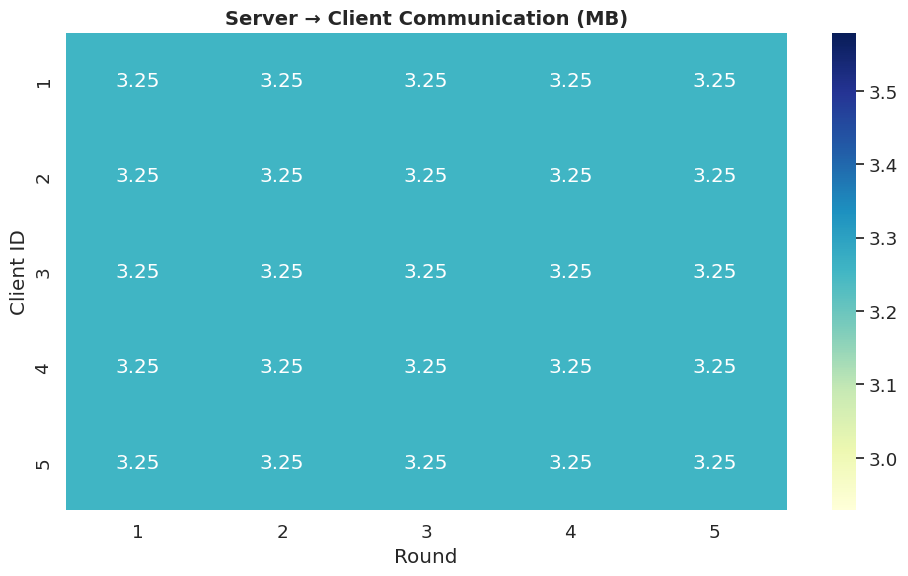

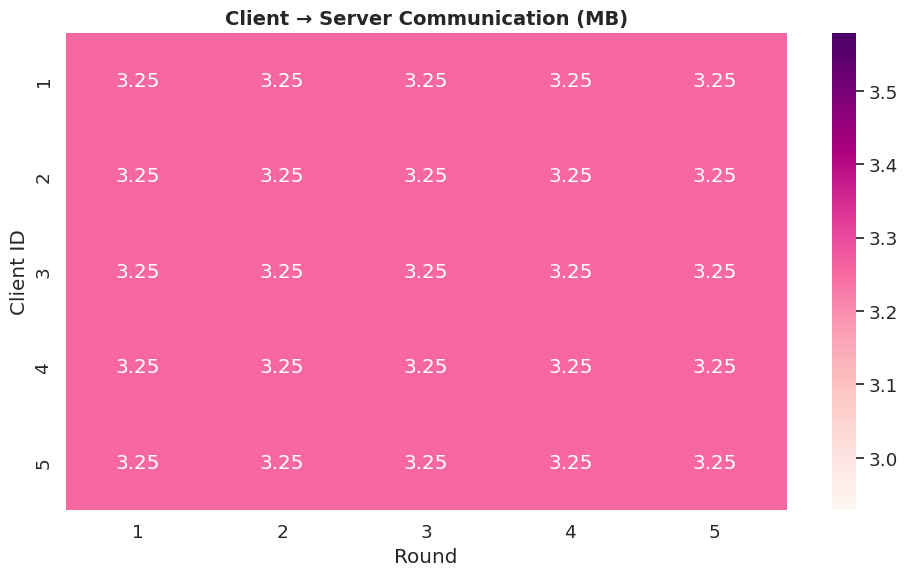

In [123]:
pivot_comm = comm_df.pivot_table(index='Client', columns='Round',
                                 values=['Bytes_Server_to_Client','Bytes_Client_to_Server'], aggfunc='sum')
sns.heatmap(pivot_comm['Bytes_Server_to_Client'] / 1e6, cmap='YlGnBu', annot=True, fmt=".2f")
plt.title("Server → Client Communication (MB)", fontsize=14, weight='bold')
plt.ylabel("Client ID")
plt.xlabel("Round")
plt.tight_layout()
plt.show()

sns.heatmap(pivot_comm['Bytes_Client_to_Server'] / 1e6, cmap='RdPu', annot=True, fmt=".2f")
plt.title("Client → Server Communication (MB)", fontsize=14, weight='bold')
plt.ylabel("Client ID")
plt.xlabel("Round")
plt.tight_layout()
plt.show()


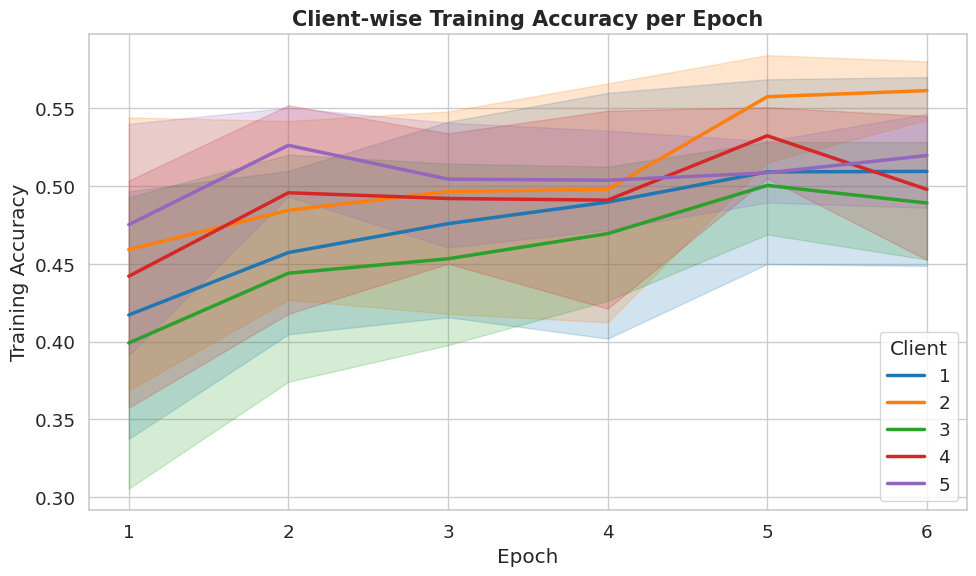

In [124]:
sns.lineplot(data=epoch_df, x='Epoch', y='TrainAcc', hue='Client', palette='tab10', lw=2.5)
plt.title("Client-wise Training Accuracy per Epoch", fontsize=15, weight='bold')
plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.tight_layout()
plt.show()


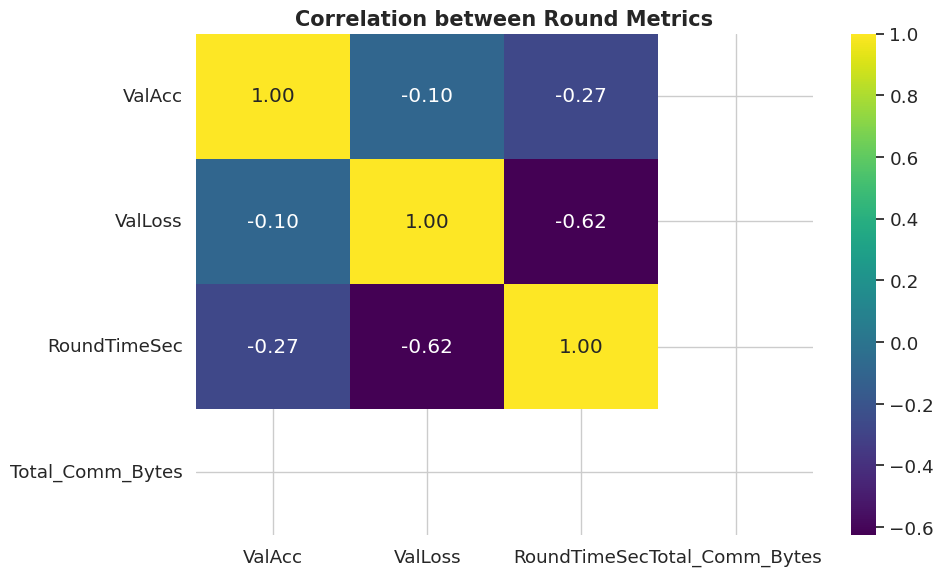

In [125]:
corr = round_df[['ValAcc', 'ValLoss', 'RoundTimeSec', 'Total_Comm_Bytes']].corr()
sns.heatmap(corr, annot=True, cmap='viridis', fmt=".2f", cbar=True)
plt.title("Correlation between Round Metrics", fontsize=15, weight='bold')
plt.tight_layout()
plt.show()


In [126]:
fig = px.scatter_3d(round_df, x='Round', y='ValAcc', z='RoundTimeSec',
                    size='Total_Comm_Bytes', color='ValLoss',
                    color_continuous_scale='plasma',
                    title="Federated Learning: Accuracy vs Time vs Communication",
                    labels={'ValAcc':'Validation Accuracy', 'RoundTimeSec':'Time (s)', 'Total_Comm_Bytes':'Comm Bytes'})
fig.update_traces(marker=dict(opacity=0.8, line=dict(width=1)))
fig.show()


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

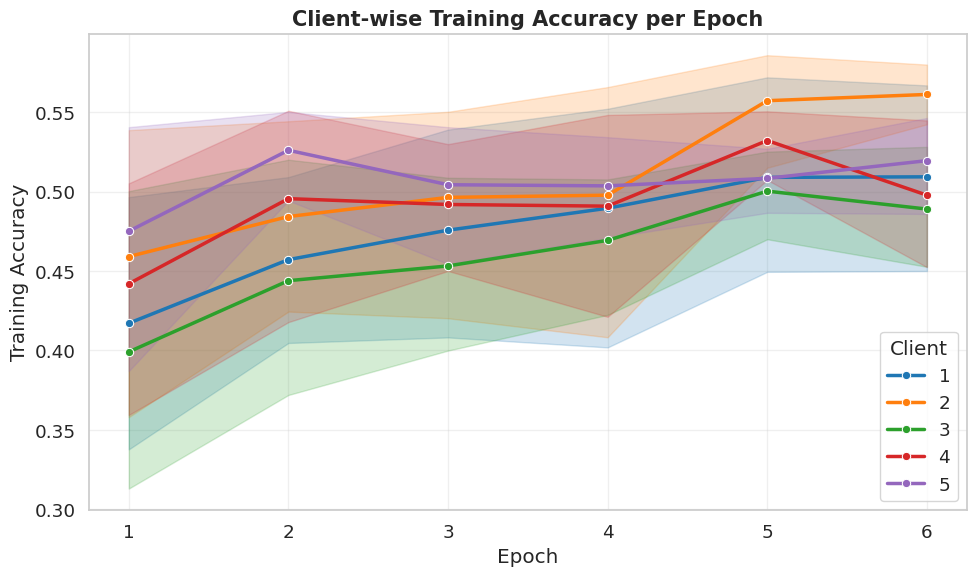

In [127]:
plt.figure(figsize=(10,6))
sns.lineplot(data=epoch_df, x='Epoch', y='TrainAcc', hue='Client', marker='o', lw=2.5, palette='tab10')
plt.title("Client-wise Training Accuracy per Epoch", fontsize=15, weight='bold')
plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.legend(title='Client', loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


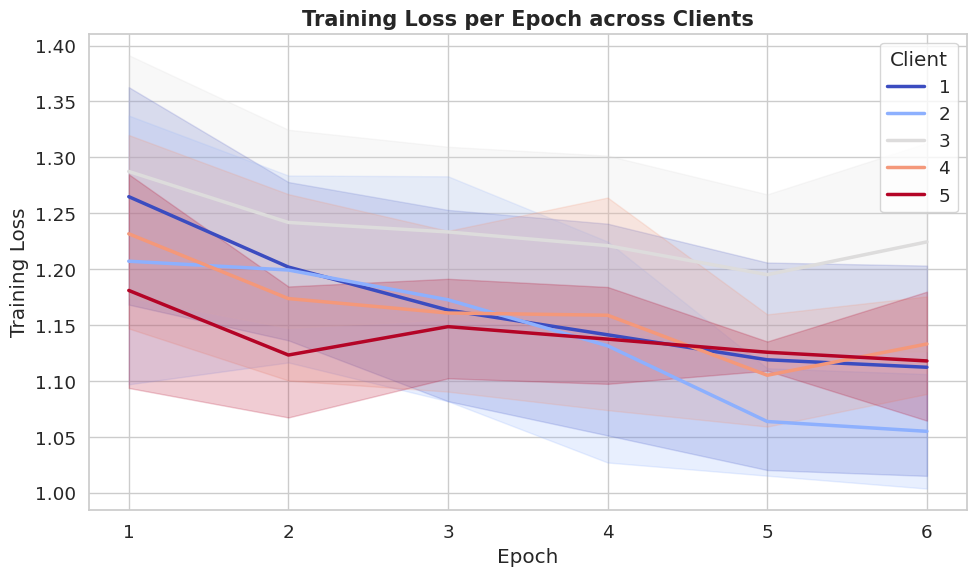

In [128]:
plt.figure(figsize=(10,6))
sns.lineplot(data=epoch_df, x='Epoch', y='TrainLoss', hue='Client', lw=2.5, palette='coolwarm')
plt.title("Training Loss per Epoch across Clients", fontsize=15, weight='bold')
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.legend(title='Client', loc='upper right')
plt.tight_layout()
plt.show()


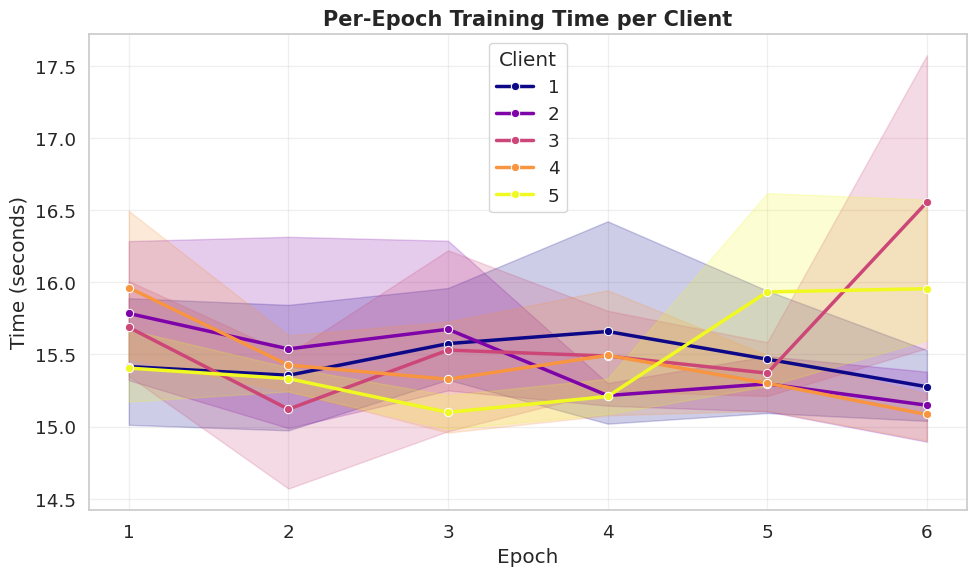

In [129]:
plt.figure(figsize=(10,6))
sns.lineplot(data=epoch_df, x='Epoch', y='TimeSec', hue='Client', lw=2.5, marker='o', palette='plasma')
plt.title("Per-Epoch Training Time per Client", fontsize=15, weight='bold')
plt.xlabel("Epoch")
plt.ylabel("Time (seconds)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


/tmp/ipykernel_10979/4071055344.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




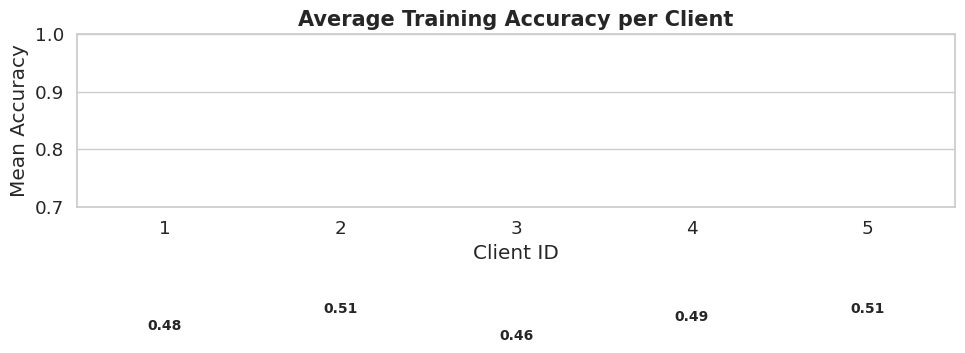

In [130]:
avg_acc = epoch_df.groupby("Client")['TrainAcc'].mean().reset_index()
sns.barplot(x="Client", y="TrainAcc", data=avg_acc, palette="crest")
plt.title("Average Training Accuracy per Client", fontsize=15, weight='bold')
plt.ylabel("Mean Accuracy")
plt.xlabel("Client ID")
for index, row in avg_acc.iterrows():
    plt.text(index, row.TrainAcc + 0.01, f"{row.TrainAcc:.2f}", ha='center', fontsize=10, weight='bold')
plt.ylim(0.7, 1.0)
plt.tight_layout()
plt.show()


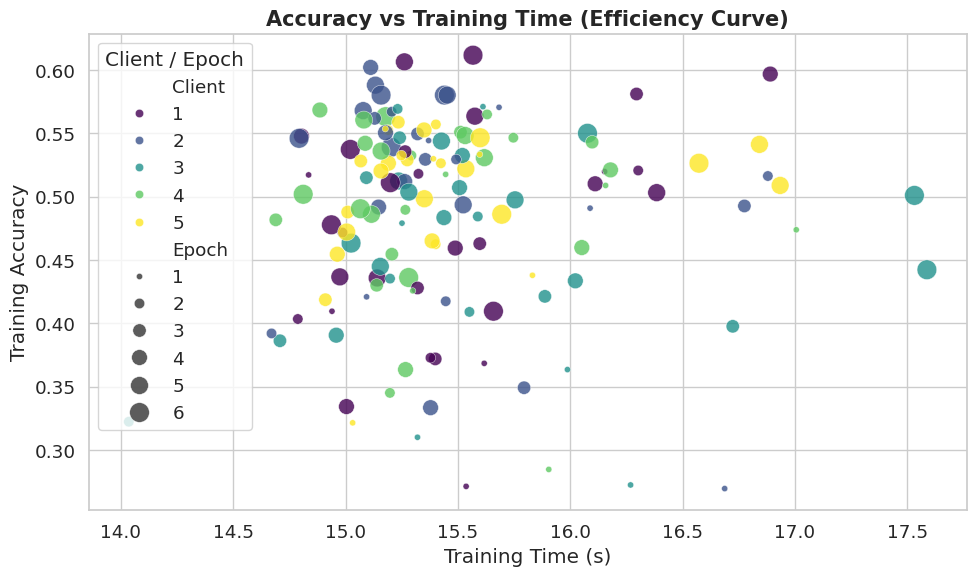

In [131]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=epoch_df, x='TimeSec', y='TrainAcc', hue='Client', size='Epoch', sizes=(20, 200), palette='viridis', alpha=0.8)
plt.title("Accuracy vs Training Time (Efficiency Curve)", fontsize=15, weight='bold')
plt.xlabel("Training Time (s)")
plt.ylabel("Training Accuracy")
plt.legend(title="Client / Epoch")
plt.tight_layout()
plt.show()


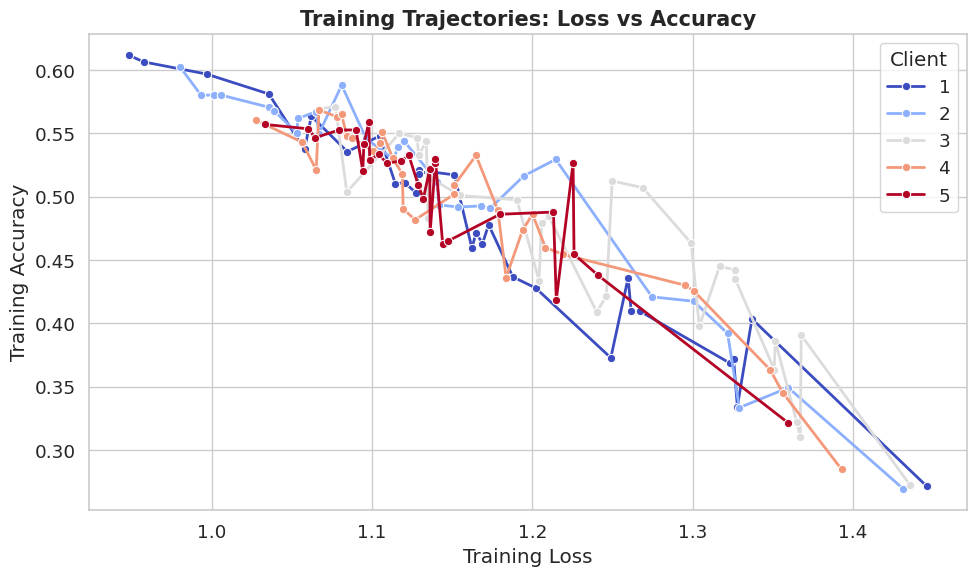

In [132]:
plt.figure(figsize=(10,6))
sns.lineplot(data=epoch_df, x='TrainLoss', y='TrainAcc', hue='Client', marker='o', lw=2, palette='coolwarm')
plt.title("Training Trajectories: Loss vs Accuracy", fontsize=15, weight='bold')
plt.xlabel("Training Loss")
plt.ylabel("Training Accuracy")
plt.tight_layout()
plt.show()


In [133]:
import plotly.graph_objects as go

client_summary = epoch_df.groupby('Client').agg({
    'TrainAcc':'mean',
    'TrainLoss':'mean',
    'TimeSec':'mean'
}).reset_index()

# normalize metrics 0-1
for col in ['TrainAcc','TrainLoss','TimeSec']:
    client_summary[col] = (client_summary[col] - client_summary[col].min()) / (client_summary[col].max() - client_summary[col].min())

categories = ['TrainAcc', 'TrainLoss', 'TimeSec']
fig = go.Figure()
for i, row in client_summary.iterrows():
    fig.add_trace(go.Scatterpolar(
        r=row[categories].tolist(),
        theta=categories,
        fill='toself',
        name=f'Client {int(row.Client)}'
    ))

fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0,1])),
    title="Client Performance Radar (Normalized Metrics)"
)
fig.show()


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

/tmp/ipykernel_10979/697950579.py:1: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




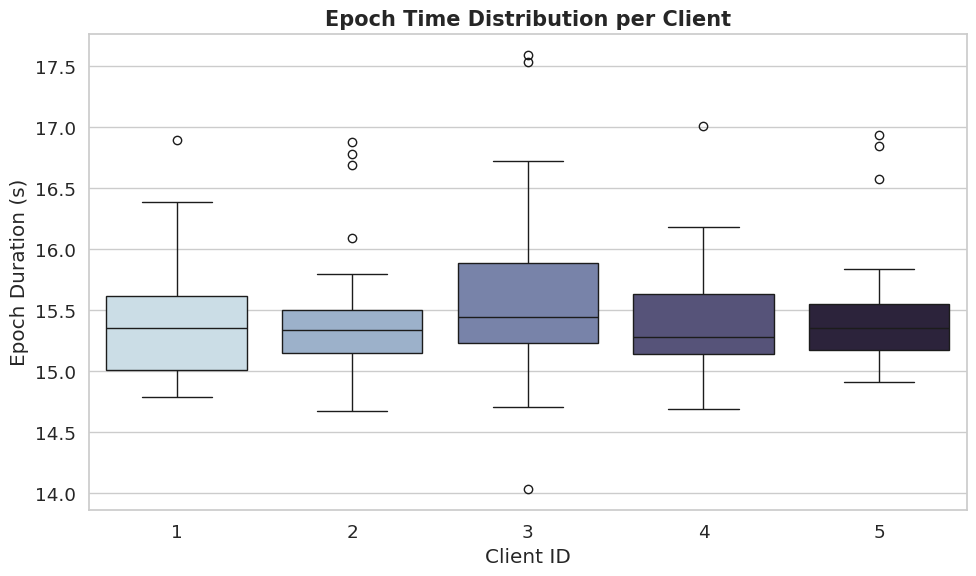

In [134]:
sns.boxplot(data=epoch_df, x='Client', y='TimeSec', palette='ch:s=.25,rot=-.25')
plt.title("Epoch Time Distribution per Client", fontsize=15, weight='bold')
plt.xlabel("Client ID")
plt.ylabel("Epoch Duration (s)")
plt.tight_layout()
plt.show()


/tmp/ipykernel_10979/1902478155.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




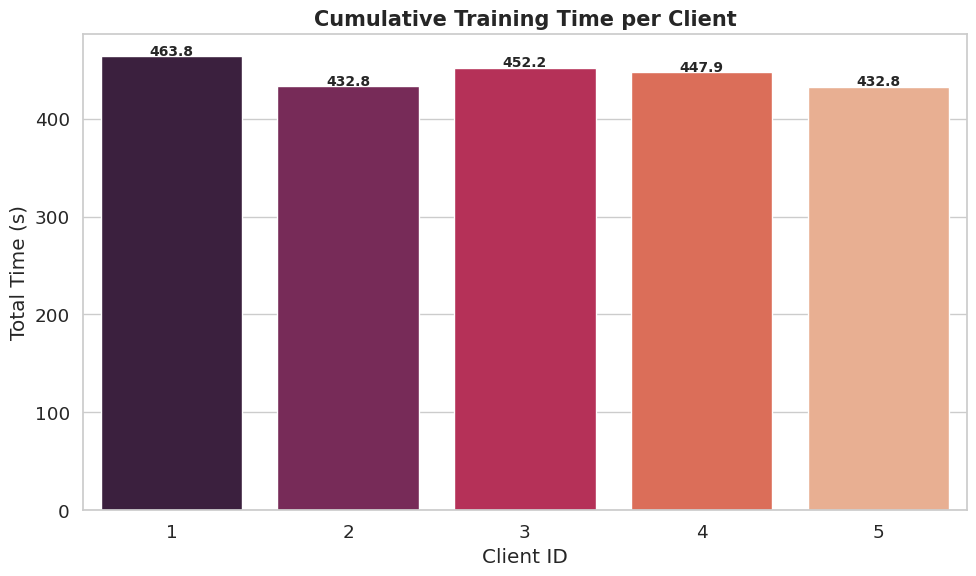

In [135]:
cum_time = epoch_df.groupby('Client')['TimeSec'].sum().reset_index()
sns.barplot(x='Client', y='TimeSec', data=cum_time, palette='rocket')
plt.title("Cumulative Training Time per Client", fontsize=15, weight='bold')
plt.xlabel("Client ID")
plt.ylabel("Total Time (s)")
for index, row in cum_time.iterrows():
    plt.text(index, row.TimeSec + 1, f"{row.TimeSec:.1f}", ha='center', fontsize=10, weight='bold')
plt.tight_layout()
plt.show()
